In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [73]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [75]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [76]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [77]:
#Data Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [78]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [79]:
df= df.drop('customerID', axis=1)

In [80]:
df.shape

(7043, 20)

In [81]:
#EDA
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [82]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

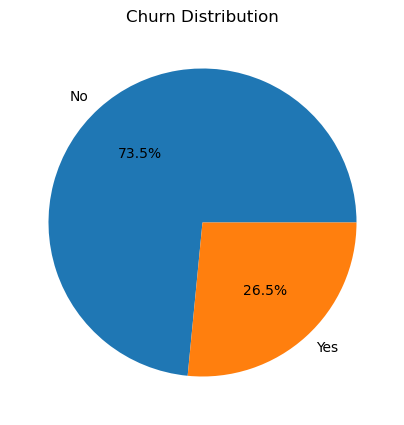

In [83]:
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(5,5))
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()

In [84]:
import sqlite3
conn = sqlite3.connect('telco.db')
df.to_sql('customers', conn, if_exists='replace', index=False)

7043

In [85]:
query = "SELECT * FROM customers LIMIT 5"
result = pd.read_sql(query,conn)
result

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [86]:
query = """
SELECT Churn, COUNT(*) as total
FROM customers
GROUP BY Churn
"""
pd.read_sql(query,conn)

,Churn,total
0,No,5174
1,Yes,1869


In [87]:
query = """
SELECT Contract, Churn, COUNT(*) as total
FROM customers
GROUP BY Contract, Churn
"""
pd.read_sql(query, conn)

,Contract,Churn,total
0,Month-to-month,No,2220
1,Month-to-month,Yes,1655
2,One year,No,1307
3,One year,Yes,166
4,Two year,No,1647
5,Two year,Yes,48


In [88]:
query = """
SELECT MonthlyCharges, Contract
FROM customers
WHERE Churn = 'Yes' AND MonthlyCharges > 80
ORDER BY MonthlyCharges DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,MonthlyCharges,Contract
0,118.35,One year
1,117.80,One year
2,117.45,Month-to-month
3,116.20,Two year
4,115.65,One year
5,115.55,One year
6,114.50,Month-to-month
7,114.20,Two year
8,113.60,Month-to-month
9,113.20,Month-to-month


In [89]:
query = """
SELECT PaymentMethod,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) / COUNT(*),2) as churn_rate_pct
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,PaymentMethod,total_customers,churned,churn_rate_pct
0,Electronic check,2365,1071,45.29
1,Mailed check,1612,308,19.11
2,Bank transfer (automatic),1544,258,16.71
3,Credit card (automatic),1522,232,15.24


In [90]:
query = """
SELECT 
    CASE
        WHEN tenure <= 12 THEN '0-1 year'
        WHEN tenure <= 24 THEN '1-2 years'
        WHEN tenure <= 48 THEN '2-4 yeras'
        ELSE '4+ years'
    END as tenure_group,
    COUNT(*) as total,
    ROUND(100.0 * SUM(CASE WHEN Churn ='Yes' THEN 1 ELSE 0 END) / COUNT(*),2) as churn_rate_pct
FROM customers
GROUP BY tenure_group
ORDER BY churn_rate_pct DESC 
"""
pd.read_sql(query, conn)

,tenure_group,total,churn_rate_pct
0,0-1 year,2186,47.44
1,1-2 years,1024,28.71
2,2-4 yeras,1594,20.39
3,4+ years,2239,9.51


In [91]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [92]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_9220\266577964.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [93]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [94]:
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df_encoded['Churn_Yes']

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [96]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [97]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    solver='liblinear'
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [98]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7146912704045423


In [99]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[735 300]
 [102 272]]
              precision    recall  f1-score   support

       False       0.88      0.71      0.79      1035
        True       0.48      0.73      0.58       374

    accuracy                           0.71      1409
   macro avg       0.68      0.72      0.68      1409
weighted avg       0.77      0.71      0.73      1409



In [100]:
print(X.columns.tolist())

['tenure', 'MonthlyCharges', 'TotalCharges']


In [101]:
for col in X.columns:
    print(col)

tenure
MonthlyCharges
TotalCharges


In [102]:
import joblib
joblib.dump(model, "churn_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!
